In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Step 1:
# Iris Flower Species Classifier

This project builds a machine learning classification system to predict iris flower species using classical ML algorithms.

Algorithms Used:
- K-Nearest Neighbors (KNN)
- Decision Tree
- Logistic Regression

Dataset:
- Iris Dataset (UCI / Kaggle)

Goal:
- Compare model performance
- Understand ML workflow
- Learn preprocessing, EDA, training, and evaluation

In [2]:
# Basic data handling
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning tools
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Machine learning models
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

print("Libraries imported successfully!")

Libraries imported successfully!


# Output
The required libraries were imported successfully.
These libraries will help us load the dataset, explore it, visualize patterns, train ML models, and evaluate their performance.

 # Step 2:
 # Import Libraries and Load Dataset

In this step, we import the required Python libraries and load the Iris dataset from the Kaggle input folder.  
After loading the data, we will check its shape, columns, and first few rows to understand the dataset structure.

In [3]:
# Basic libraries for data handling
import pandas as pd
import numpy as np

# Libraries for visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Show plots inside notebook
%matplotlib inline

# Load dataset
data_path = "/kaggle/input/datasets/organizations/uciml/iris/Iris.csv"
df = pd.read_csv(data_path)

# Display first 5 rows
df.head()

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/datasets/organizations/uciml/iris/Iris.csv'

# STEP 3 — Data Preprocessing

## Feature and Target Separation

Machine learning models use input features (X) to predict the target variable (y).  
Here, flower measurements are used as features, while Species is the target.

In [ ]:
# Features
X = df.drop(["Id", "Species"], axis=1)

# Target
y = df["Species"]

# Display first rows
X.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


# Output
The output shows the numerical feature columns used for machine learning.  
These features will help the model identify flower species.

## Label Encoding

Machine learning algorithms work with numerical values.  
In this step, flower species names are converted into numbers.

In [4]:
from sklearn.preprocessing import LabelEncoder

# Create encoder
encoder = LabelEncoder()

# Convert text labels into numbers
y = encoder.fit_transform(y)

# Display encoded values
y[:10]

NameError: name 'y' is not defined

# Output
The species names are converted into numerical labels.  
This allows machine learning models to process the target variable correctly.

## Train-Test Split

The dataset is divided into training and testing sets.  
The training set is used for learning, while the testing set evaluates model performance on unseen data.

In [ ]:
from sklearn.model_selection import train_test_split

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Check shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (120, 4)
X_test shape: (30, 4)


# Output
The dataset is divided into training and testing sets.  
80% of the data is used for training and 20% is used for testing.

## Feature Scaling

Feature scaling standardizes numerical values so that all features contribute equally during model training.  
This is especially important for distance-based algorithms like KNN.

In [ ]:
from sklearn.preprocessing import StandardScaler

# Create scaler
scaler = StandardScaler()

# Fit and transform training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform testing data
X_test_scaled = scaler.transform(X_test)

# Display first rows
X_train_scaled[:5]

array([[-1.72156775, -0.32483982, -1.34703555, -1.32016847],
       [-1.12449223, -1.22612948,  0.41429037,  0.65186742],
       [ 1.14439475, -0.55016223,  0.58474127,  0.25746024],
       [-1.12449223,  0.12580502, -1.29021859, -1.45163753],
       [-0.40800161, -1.22612948,  0.13020555,  0.12599118]])

# Output
The feature values are standardized around zero with unit variance.  
Scaling helps machine learning algorithms compare features more effectively.

## Final Prepared Data

The dataset is now fully prepared for machine learning model training.

In [ ]:
print("Training data shape:", X_train_scaled.shape)
print("Testing data shape:", X_test_scaled.shape)

Training data shape: (120, 4)
Testing data shape: (30, 4)


# Output
The training and testing datasets are successfully prepared for machine learning algorithms.  
The data is now cleaned, encoded, split, and scaled.

# STEP 4 — Train ML Model (K-Nearest Neighbors)


## K-Nearest Neighbors (KNN) Model

KNN classifies data points based on the nearest neighboring samples.  
The algorithm predicts the class by majority voting among nearby data points.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Create model
knn = KNeighborsClassifier(n_neighbors=5)

# Train model
knn.fit(X_train_scaled, y_train)

# Make predictions
y_pred_knn = knn.predict(X_test_scaled)

# Accuracy
knn_accuracy = accuracy_score(y_test, y_pred_knn)

print("KNN Accuracy:", knn_accuracy)

KNN Accuracy: 0.9333333333333333


# Output
The KNN model is trained using the training dataset and evaluated on testing data.  
The accuracy score shows how correctly the model predicts flower species.

## Confusion Matrix

A confusion matrix shows how many predictions were correct and where classification errors occurred.

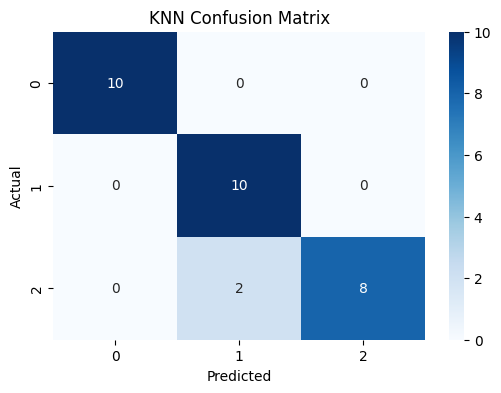

In [ ]:
from sklearn.metrics import confusion_matrix

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred_knn)

# Plot heatmap
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

# Labels
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KNN Confusion Matrix")

# Show plot
plt.show()

# Output
The confusion matrix shows the number of correct and incorrect predictions for each flower species.  
Most prediction errors occur between Versicolor and Virginica.

## Classification Report

The classification report provides precision, recall, and F1-score for each flower species.

In [ ]:
from sklearn.metrics import classification_report

# Print report
print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.83      1.00      0.91        10
           2       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



# Output
The classification report evaluates model performance for each flower species separately.  
It includes precision, recall, and F1-score values.